In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              8575, # Ramboton
                              6980, # Vulbis
                              7754, # Dofus ocre
                              13344, # Dolmanax
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 5,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 75,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        # 31 : {
                        #     "target": 6, # alcance
                        #     "strength": 0.75,  # Penalty for not meeting the target
                        # }
                    },
                    "upper": {}
                },
                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    # 8:1,  # Exo MP
                    },
                "distributed_points": {
                    # 9: 995,  # Vitality
                },
                "elements" : [
                    # 36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "melee" : False,
                "ranged" : 3 # True or minimum range 
            },
        }

In [3]:
import pandas as pd
dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
Items[Items["name"].str.contains("casco de miau", case=False)]

,name,set,level
17579,Casco de Miauvizor,Set de Miauvizor,200


In [5]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2652
Total item sets: 147
Total pools:
   16 with sizes [68, 26, 71, 71, 62, 81, 39, 88, 69, 412, 324, 324, 324, 324, 324, 324]
Total combinations: 10^33.70


In [6]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solut

## Analysis

In [7]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 114


In [14]:
analyzer.report_extended_results()

Solution 0:
	Fitness: 286.966
	Weapon damage: 1147.864
		Weapon: Varita Liana
		AP Cost: 4
		Casts per turn: 1
	Spell damage: 1179.1775
	Preferences:
		PA : 12.0
		PM : 5.0
		% crítico : 76.0
		vitalidad : 4000.0
		% resistencia neutral : 17.0
		% resistencia al fuego : 24.0
		% resistencia al aire : 28.0
		% resistencia al agua : 41.0
		% resistencia a la tierra : 21.0
	Characteristics:
		agilidad: 230.0
		suerte: 575.0
		inteligencia: 465.0
		fuerza: 480.0
		vitalidad: 4000.0
		sabiduría: 390.0
	Items:
		Type	Description	Level	ID
		Amuleto	Amuleto de Wulán	200	24029
		Anillo	Anillo de famosillo	200	19608
		Anillo	Coconillo	200	21223
		Bota	Botas de Miauvizor	200	17578
		Capa	Capa de Miauvizor	200	17580
		Cinturón	Cintáceo	200	15699
		Dofus	Dofus Púrpura	110	694
		Dofus	Dofus Turquesa	160	739
		Dofus	Dofus de los hielos	180	7043
		Escudo	Cocoscudo	200	21225
		Mascota	Lokulto	20	13673
		Sombrero	Kidiboina	200	15694
		Trofeo	Destructor de agua mayor	150	12690
		Trofeo	Torturador neutral

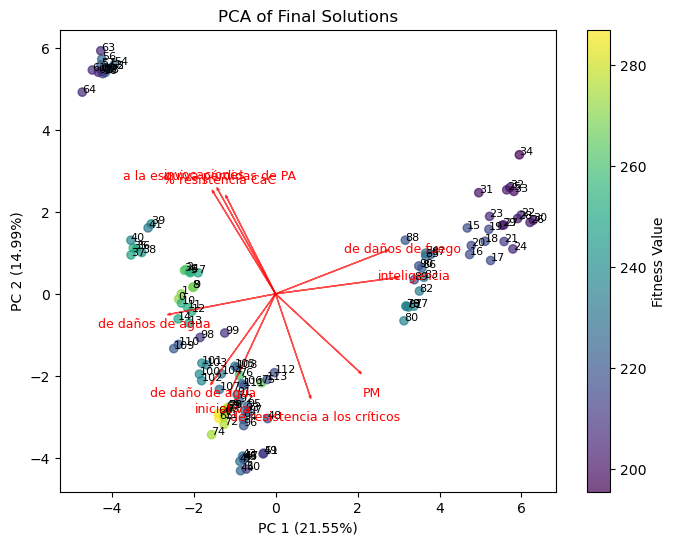

In [9]:
analyzer.plot_pca()

In [10]:
candidate = analyzer.candidates[0]
analyzer.report_results([candidate])
candidate.totals_summary()

Solution 0:
	Fitness: 271.29
	Weapon damage: 1085.16
		Weapon: Arco de Wulán
		AP Cost: 4
		Casts per turn: 1
	Spell damage: 1277.4
	Preferences:
		PA : 12.0
		PM : 5.0
		% crítico : 75.0
		vitalidad : 4100.0
		% resistencia neutral : 20.0
		% resistencia al fuego : 15.0
		% resistencia al aire : 23.0
		% resistencia al agua : 38.0
		% resistencia a la tierra : 34.0
	Characteristics:
		agilidad: 160.0
		suerte: 660.0
		inteligencia: 290.0
		fuerza: 700.0
		vitalidad: 4100.0
		sabiduría: 345.0
	Items:
		Type	Description	Level	ID
		Amuleto	Amuleto de estrígido	200	14094
		Anillo	Brazalete de melenutrof	200	15190
		Anillo	Anillo de Corrupción	200	22205
		Arco	Arco de Wulán	200	24031
		Bota	Ballenotas	200	15692
		Capa	Capa Pología	198	14168
		Cinturón	Cintáceo	200	15699
		Dofus	Dofus Púrpura	110	694
		Dofus	Dofus Turquesa	160	739
		Dofus	Dofus de los hielos	180	7043
		Escudo	Cuadrifolio	193	18700
		Mascota	Lokulto	20	13673
		Sombrero	Diadema de Wulán	200	24030
		Trofeo	Suertudo mayor	150	1

,description,value
0,Intercambiable:,0.0
8,PM,5.0
9,vitalidad,4100.0
10,sabiduría,345.0
12,PA,12.0
13,inteligencia,290.0
16,% resistencia al aire,23.0
17,% resistencia al agua,38.0
22,suerte,660.0
25,prospección,46.0


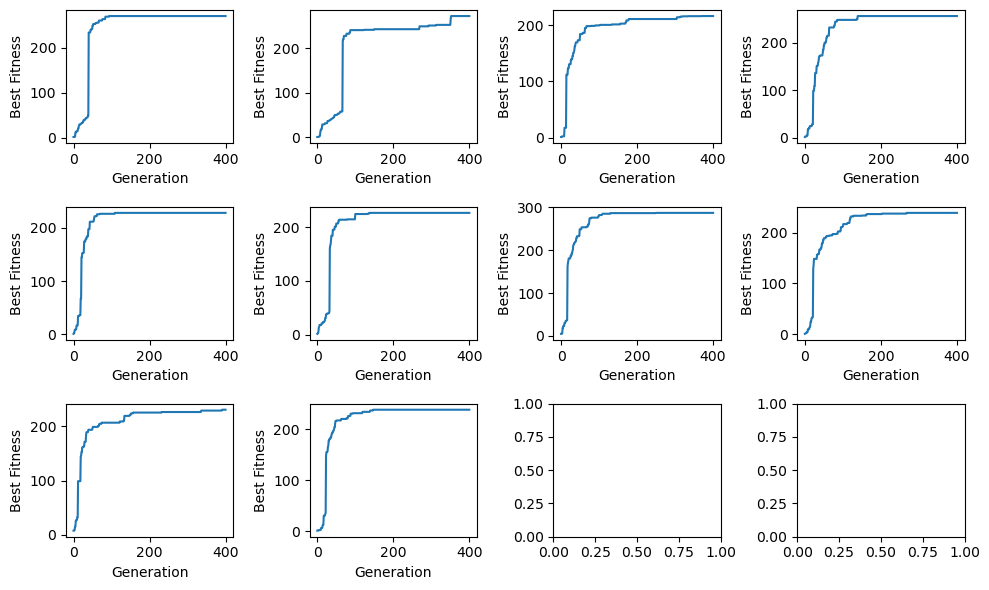

In [11]:
analyzer.report_generations()

In [12]:
assert False

AssertionError: 

In [15]:
# Current
chr = Chromosome([
 			24029, # Amuleto de Wulán
			19608, # Anillo de famosillo
			21223, # Coconillo
			17578, # Botas de Miauvizor
			17580, # Capa de Miauvizor
			15699, # Cintáceo
			694, # Dofus Púrpura
			739, # Dofus Turquesa
			7043, # Dofus de los hielos
			21225, # Cocoscudo
			13673, # Lokulto
			15694, # Kidiboina
			12690, # Destructor de agua mayor
			13777, # Torturador neutral mayor
			13825, # Potente mayor
			11759, # Varita Liana
 			],
                 opt)
chr.fitness

286.966

In [ ]:
Items[Items["name"].str.contains("kuko")]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)